# Tutorial: Solving Rule-Compliant Trajectory Repairing Problems
This tutorial demonstrates how we can use the existing trajectory repairing framework to solve real planning problems that the initially-planned trajectory is not rule-compliant

## 0. Preparation
Before you proceed with this tutorial, make sure that

* you have gone through the tutorials on **CommonRoad Input-Output**
* you have installed all necessary modules for **CommonRoad Repairer** according to the installation manual.

Let's start with importing relevant modules and classes for setting up the CommonRoad (CR) scenario.

In [5]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
path_notebook = os.getcwd()

# CommonRoad packages
from commonroad.common.file_reader import CommonRoadFileReader

from crrepairer.smt.monitor_wrapper import STLRuleMonitor
from crrepairer.repairer.smt_repairer import SMTTrajectoryRepairer
from crrepairer.utils.configuration import RepairerConfiguration

# add the root folder to python path
# sys.path.append(os.path.join(path_notebook, "../../"))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Loading CR Scenario and Planning Problem Set
In the next step, we load CommonRoad scenarios and their planning problems.

In [17]:
path_scenario = os.path.join(path_notebook, "../scenarios/")
id_scenario = 'DEU_Gar-1_1_T-1'

# read in scenario and planning problem set, lanelet_assignment needs to be True
scenario, planning_problem_set = CommonRoadFileReader(path_scenario + id_scenario + '.xml').open(
    lanelet_assignment=True)
# retrieve the first planning problem in the problem set
planning_problem = list(planning_problem_set.planning_problem_dict.values())[0]

config = RepairerConfiguration.load(f"../config/{str(scenario.scenario_id)}.yaml", str(scenario.scenario_id))
config.update()

## 2. Select the ego vehicle, whose initial trajectory violates traffic rules
We need to define the rule and the vehicle ID

In [13]:
ego_id = 200
rule = "R_G1"
# ego vehicle with the initially-planned trajectory
ego_initial = scenario.obstacle_by_id(ego_id)

## 3. Trajectory Repairing
### 3.1 Define the rule abstracter and initialize the trajectory repairing framework
We use the lazy SMT solver for our trajectory repairing problem. This method abstracts the input formula to a propositional one and feeds it to a SAT solver to suggest possible assignments. The T-solver checks the satisfiability of the obtained assignment in a theory T (T-consistency) to refine the formula and guide the SAT solver. Therefore, we need first to define the rule abstracter and then use it to initialize the trajectory repairing problem with the initially-planned trajectory.

In [19]:
# rule_monitor = STLRuleMonitor(scenario,
#                               planning_problem,
#                               ego_id,
#                               rule)
rule_monitor = STLRuleMonitor(config)
# repairer = SMTTrajectoryRepairer(rule_monitor,
#                                  ego_initial)
repairer = SMTTrajectoryRepairer(rule_monitor,
                                 ego_initial, 
                                 config)

===== formula in NNF:  a | d | ~b | ~c
Proposition 'keeps_safe_distance_prec__0_1' (a) of rule R_G1 has ttv_value: -0.0028297319980386693 and ttv_h_min: -0.02076337783725667
Proposition 'in_front_of__0_1' (b) of rule R_G1 has ttv_value: 0.06936074419243753 and ttv_h_min: -0.06936074419243753
Proposition 'in_same_lane__0_1' (c) of rule R_G1 has ttv_value: 0.11323200712573005 and ttv_h_min: -0.11516047920240487
Proposition 'once[0,3]((cut_in__1_0)and(previous(not(cut_in__1_0))))' (d) of rule R_G1 has ttv_value: -0.022388374085965328 and ttv_h_min: -0.022388374085965328
# =========== Traffic Rule Monitor ========== #
	The ego vehicle (ID: 200)'s initial trajectory violates the traffic rule: R_G1.
	Violation occurred at time step: 14, with respect to vehicle ID: 202.
# =========================================== #
* 	<SATSolver>: the formula in CNF is a | d | ~b | ~c
Set parameter Username
Set parameter LicenseID to value 2764063
Academic license - for non-commercial use only - expires 202

### 3.2 start repairing
1. "SATSolver": find the cut-off state
2. "TSolver": use QP-planner to obtain the repaired trajectory

In [20]:
# call the repairing function
repaired_traj = repairer.repair()
# updated ego vehicle with the repaired trajectory
ego_vehicle = repairer.convert_traj_to_ego_vehicle(ego_initial.obstacle_shape,
                                                   ego_initial.initial_state,
                                                   repaired_traj)
# we use the existing CommonRoad vehicle models, thus, the vehicle dimension needs to be updated
ego_initial.prediction.shape = ego_vehicle.prediction.shape

******** Trajectory Repairing starts! ********
* 1. iteration...
* 	<SATSolver>: model is {'a'}
* 	<SATSolver>: SAT reasoning time: 0.000s
* 	<TSolver>: selected propositions: a keeps_safe_distance_prec__0_1 = -0.0028297319980386693
* 	<TSolver>: Unfortunately, the model predictive robustness is not really computed
* 	<TSolver>: compliant maneuver /brake/ is selected
* 	<Tsolver>: brake start from 0
* 	<Tsolver>: tc = 1.2, tv = 1.4
* 	<Tsolver>: run time 0.021s
* 	<TSolver>: MIQP planner is invoked
* 	<TSolver>: initialization time 0.000s
* 		 MIQP Longitudinal optimization
* 		 -- reachset takes 0.001 s --
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 24.04.3 LTS")

CPU model: Intel(R) Core(TM) i9-14900HX, instruction set [SSE2|AVX|AVX2]
Thread count: 32 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 127 rows, 46 columns and 321 nonzeros (Min)
Model fingerprint: 0xa3e2ccb7
Model has 20 linear objective coefficients and an obj

### 3.3 Visualize the result
1. initial configuration
2. repaired configuration

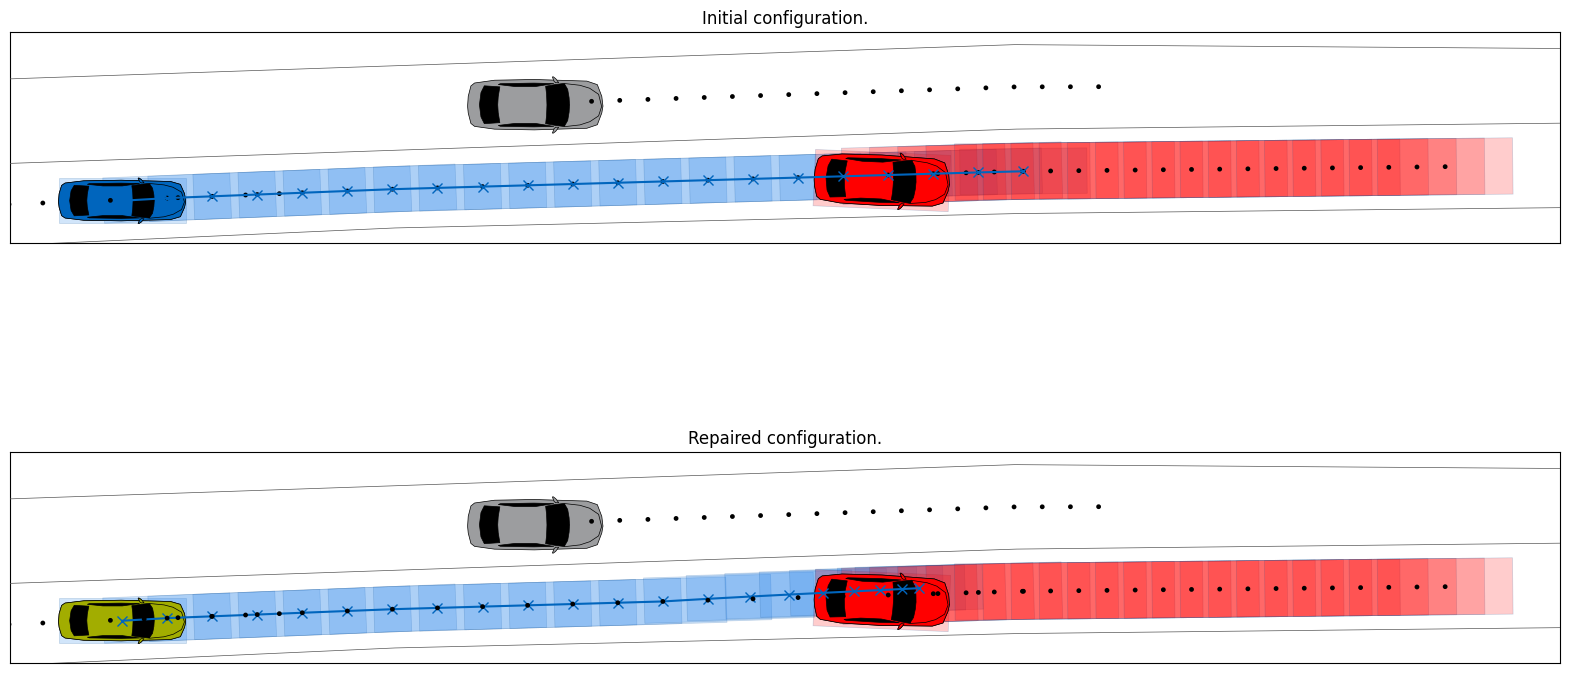

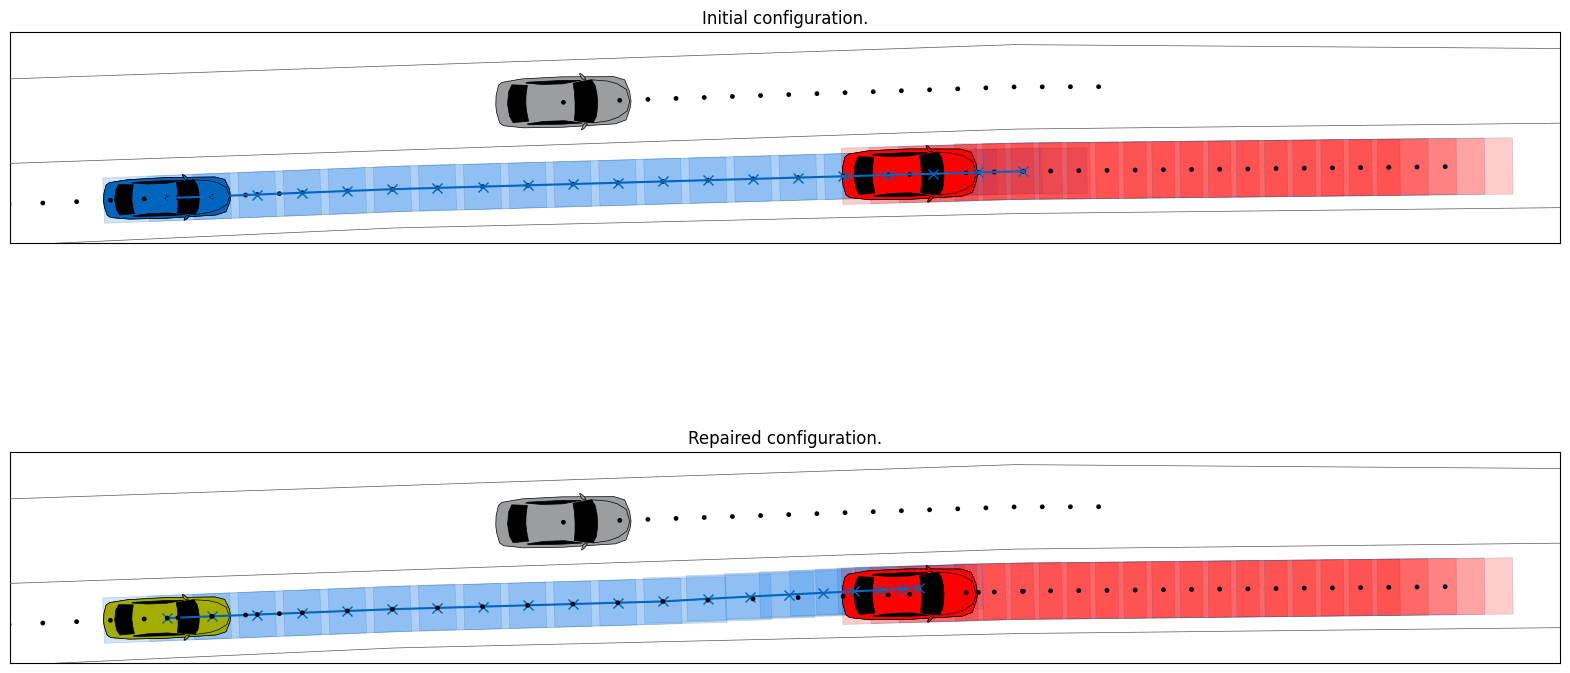

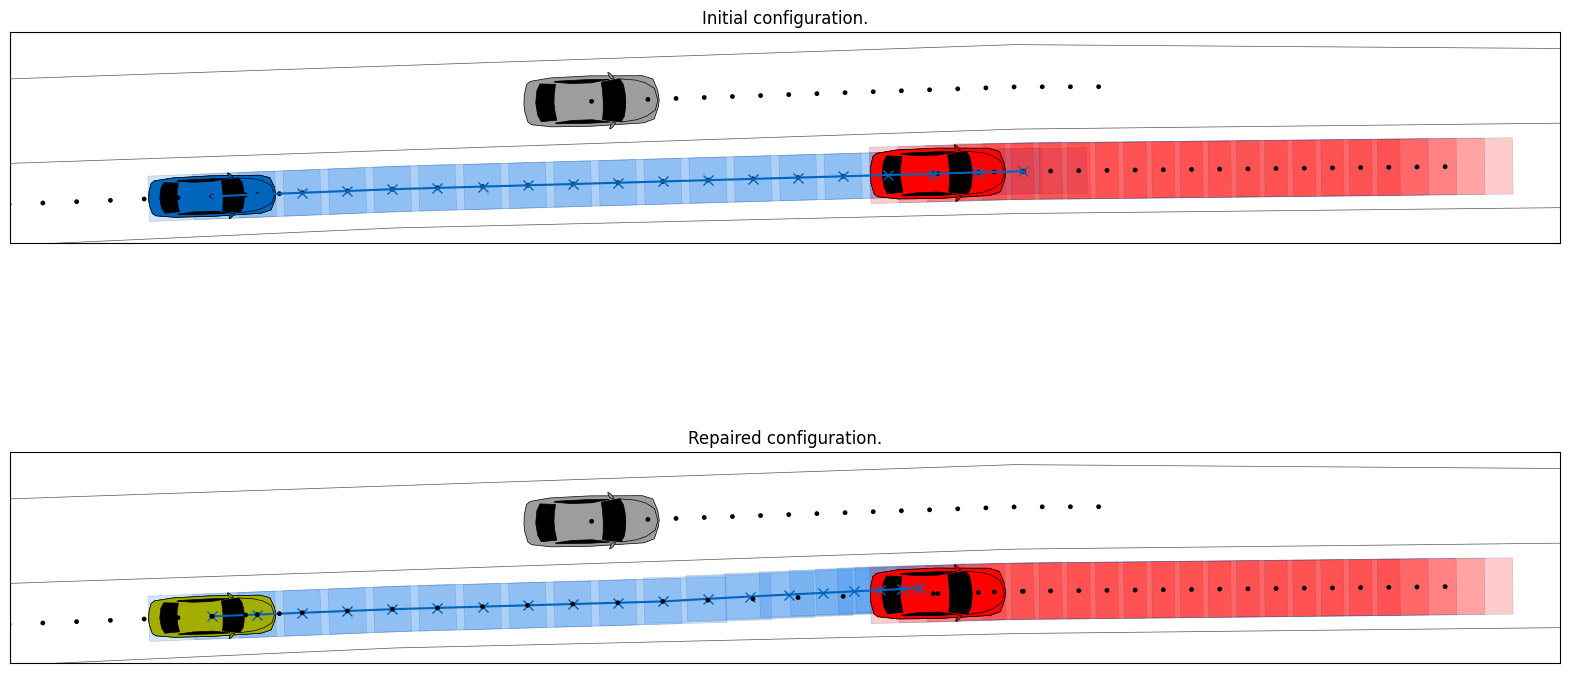

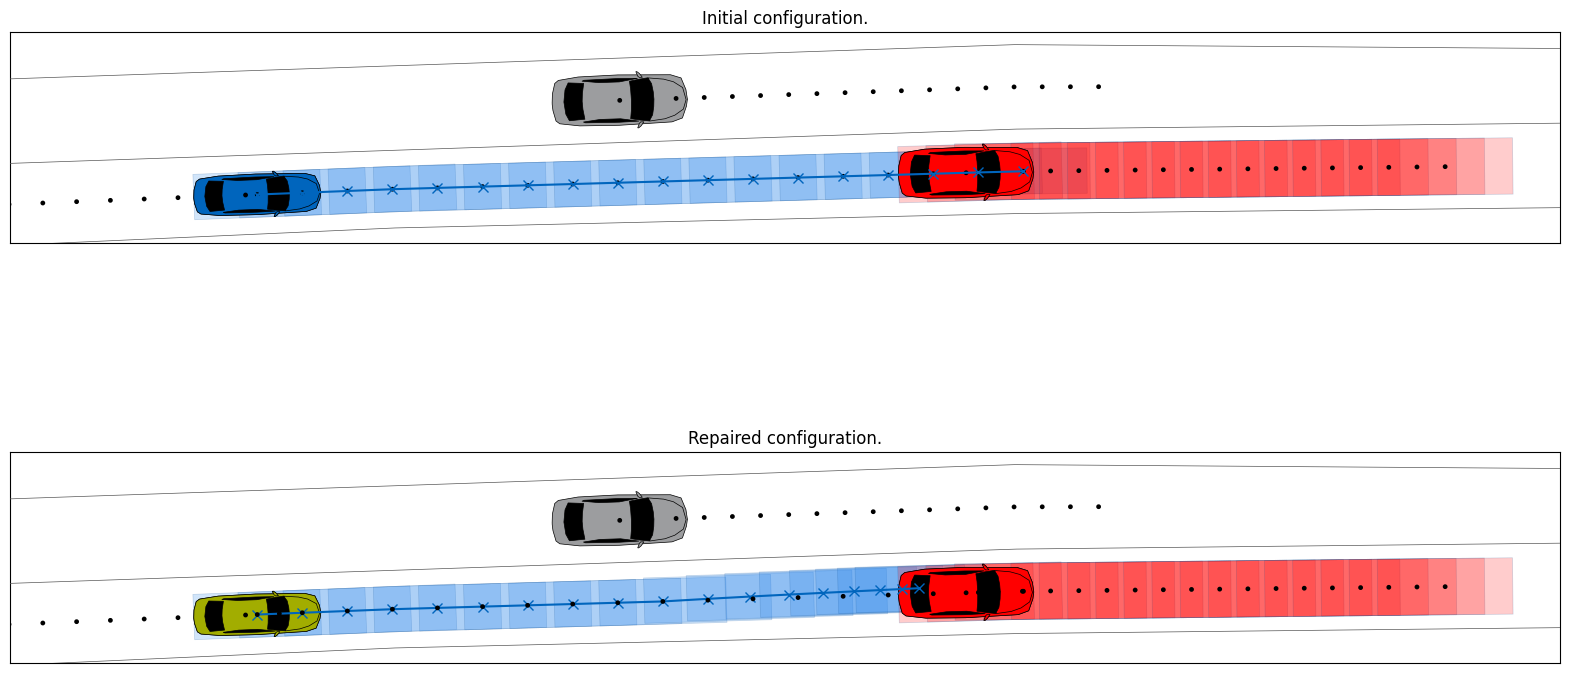

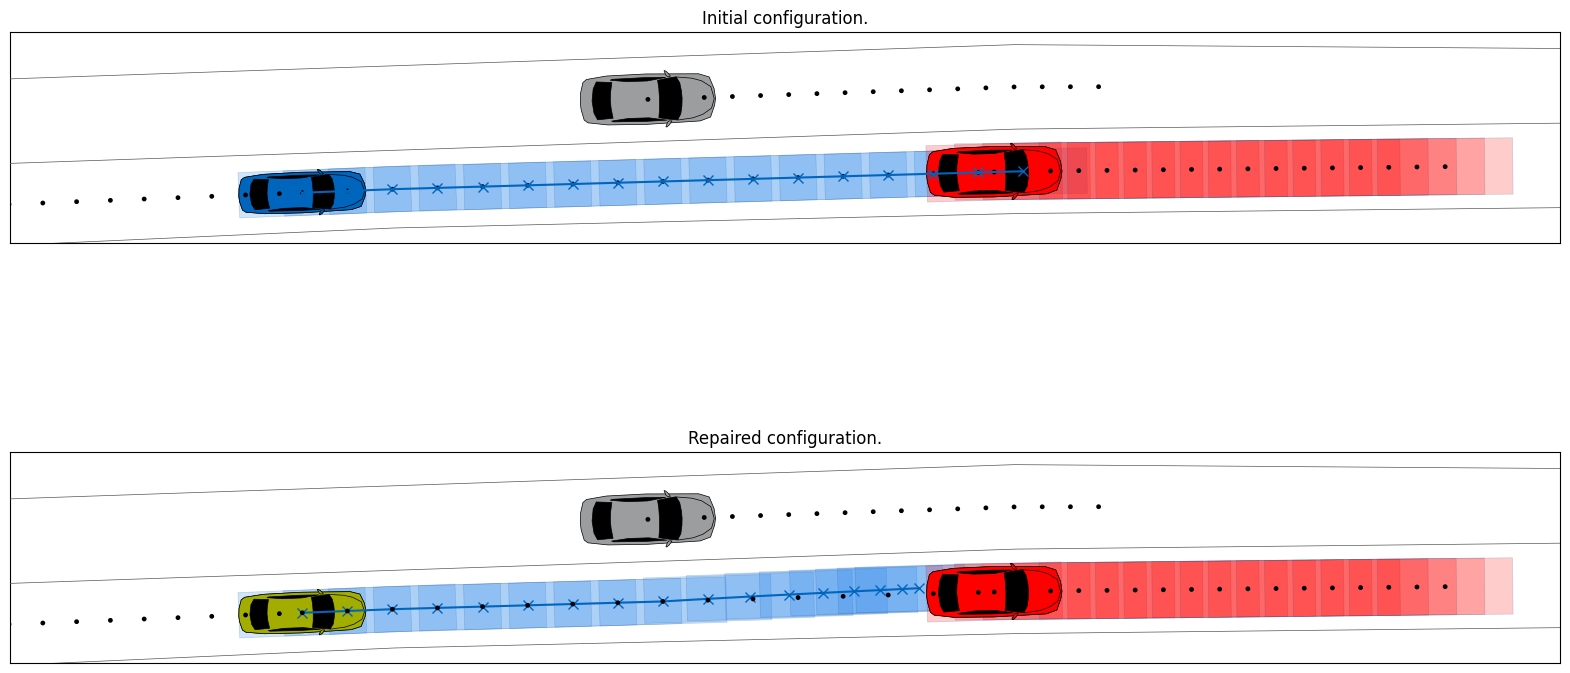

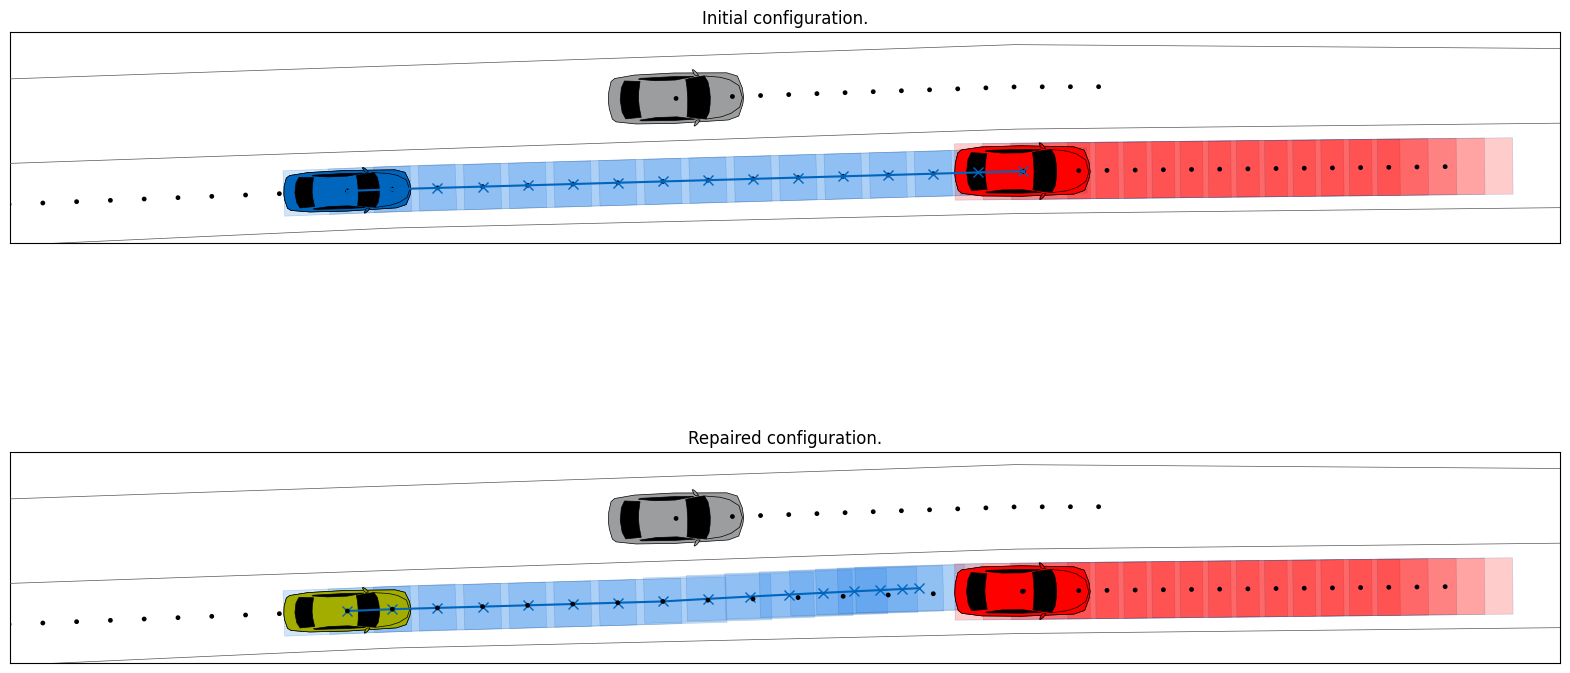

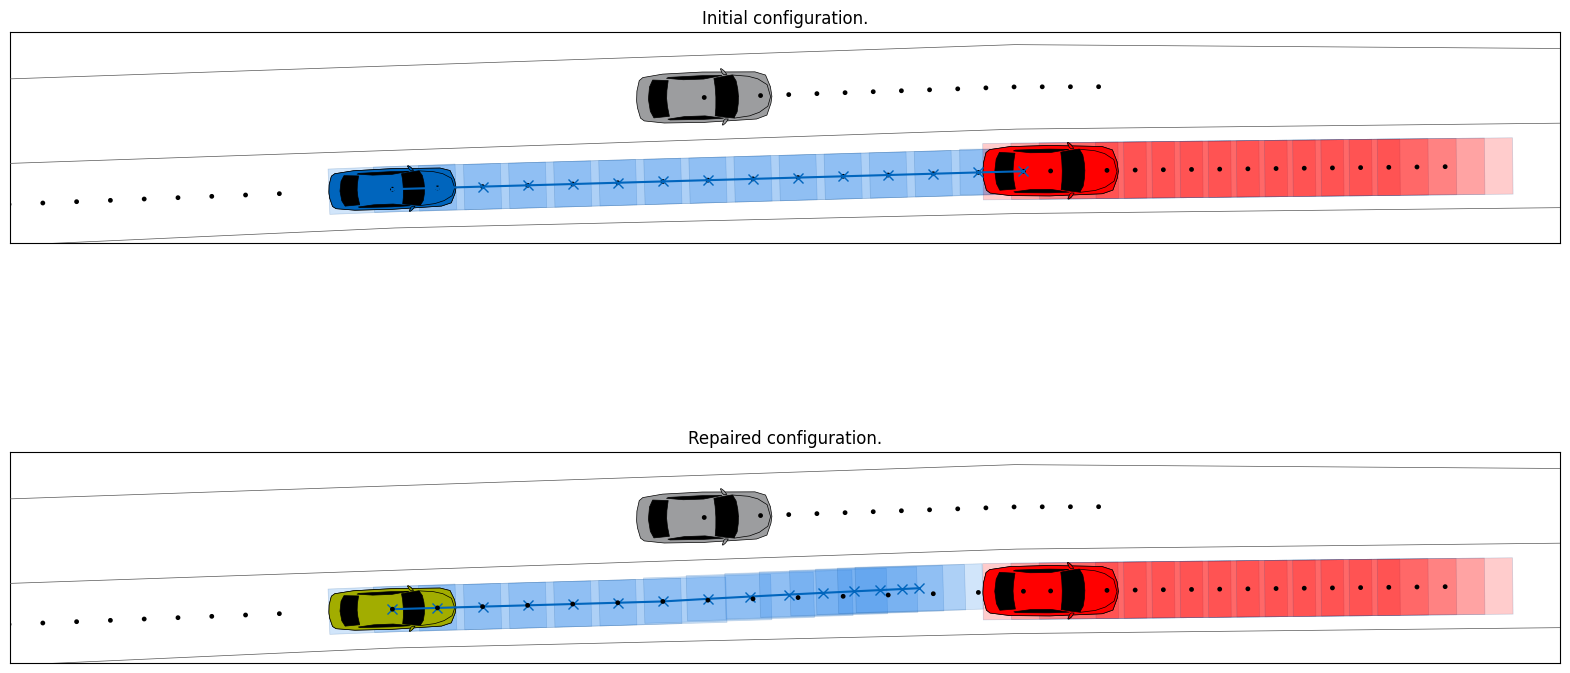

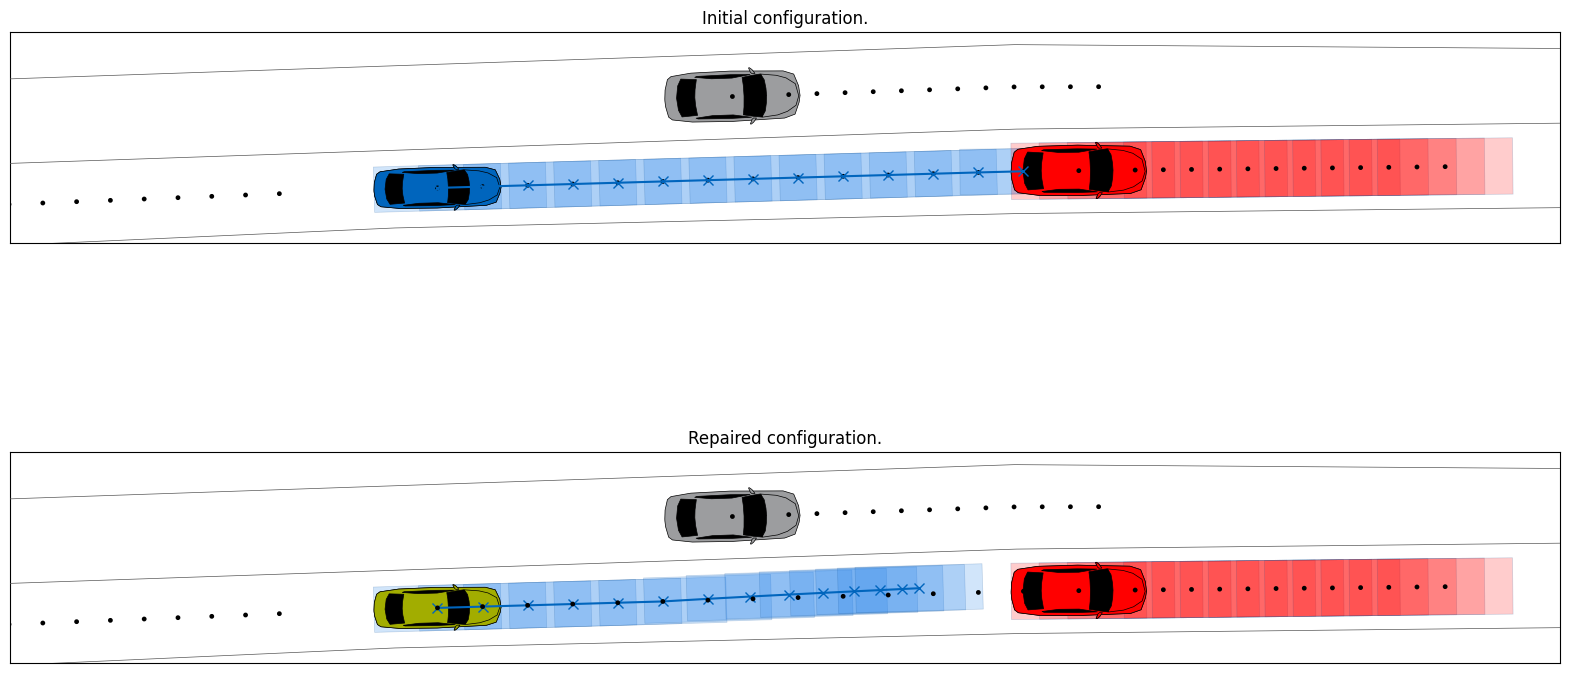

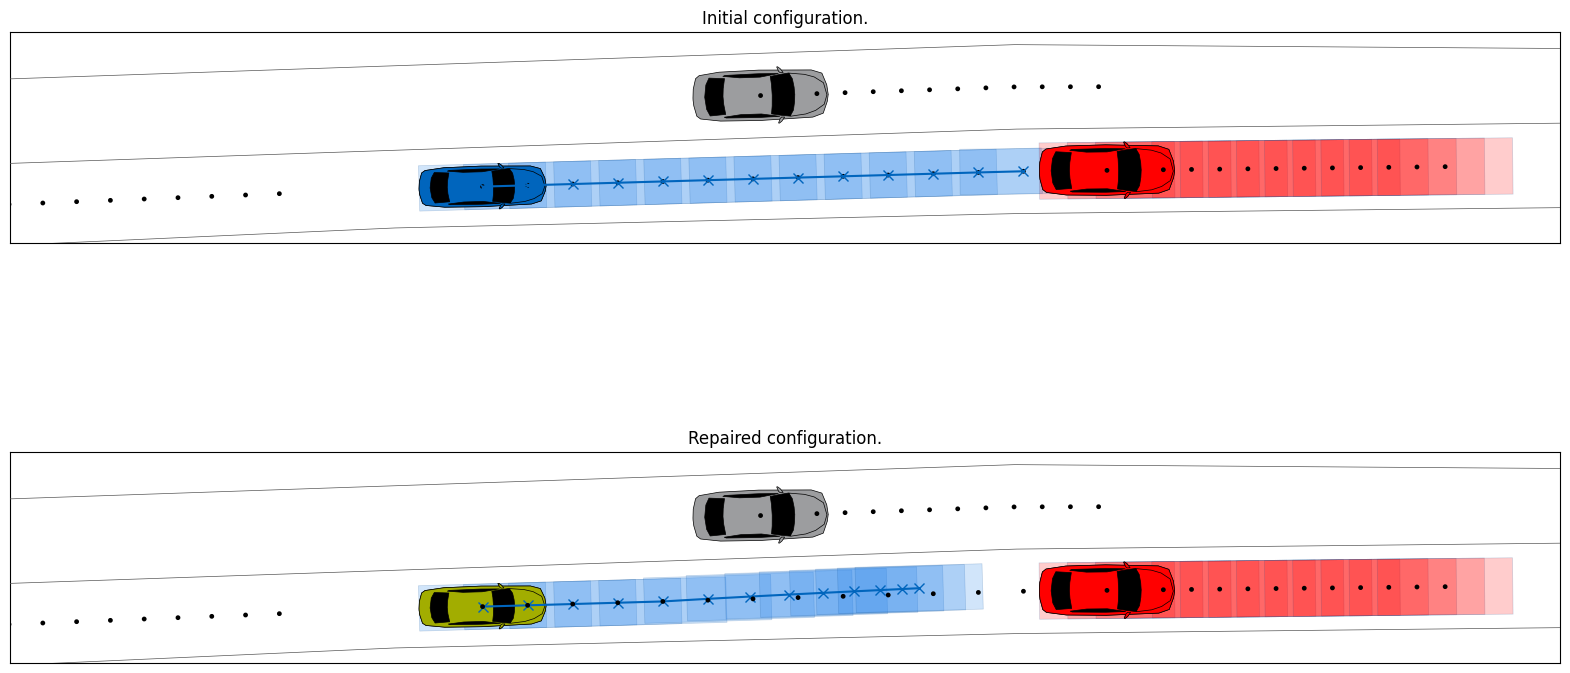

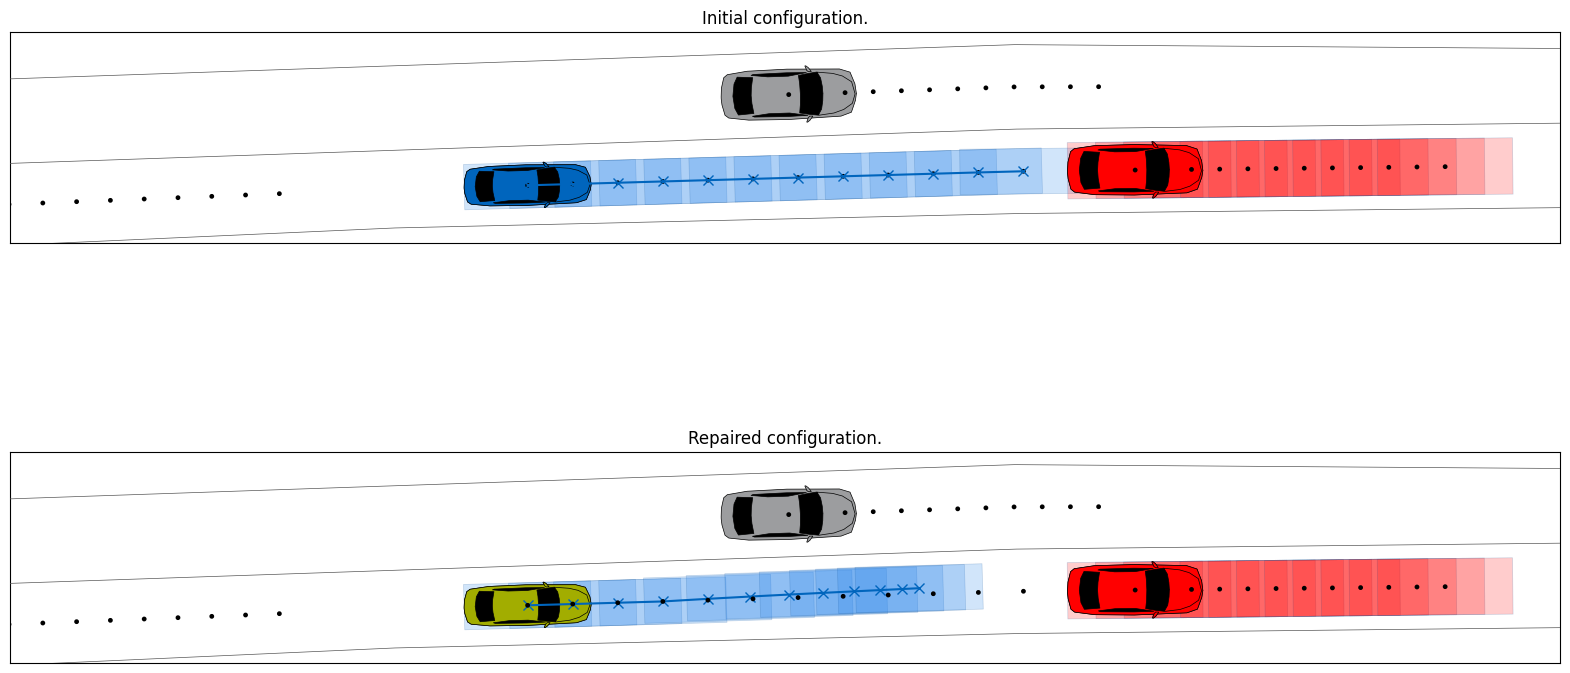

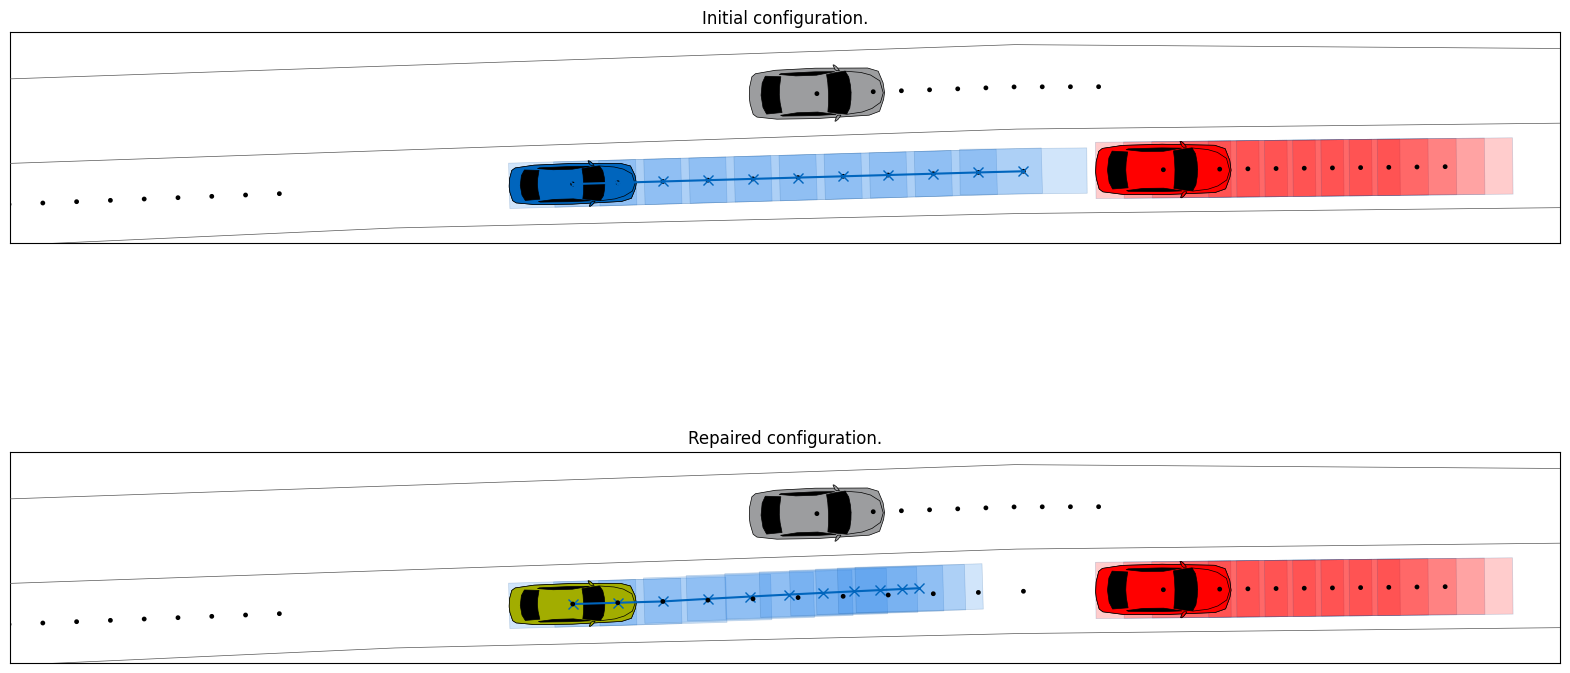

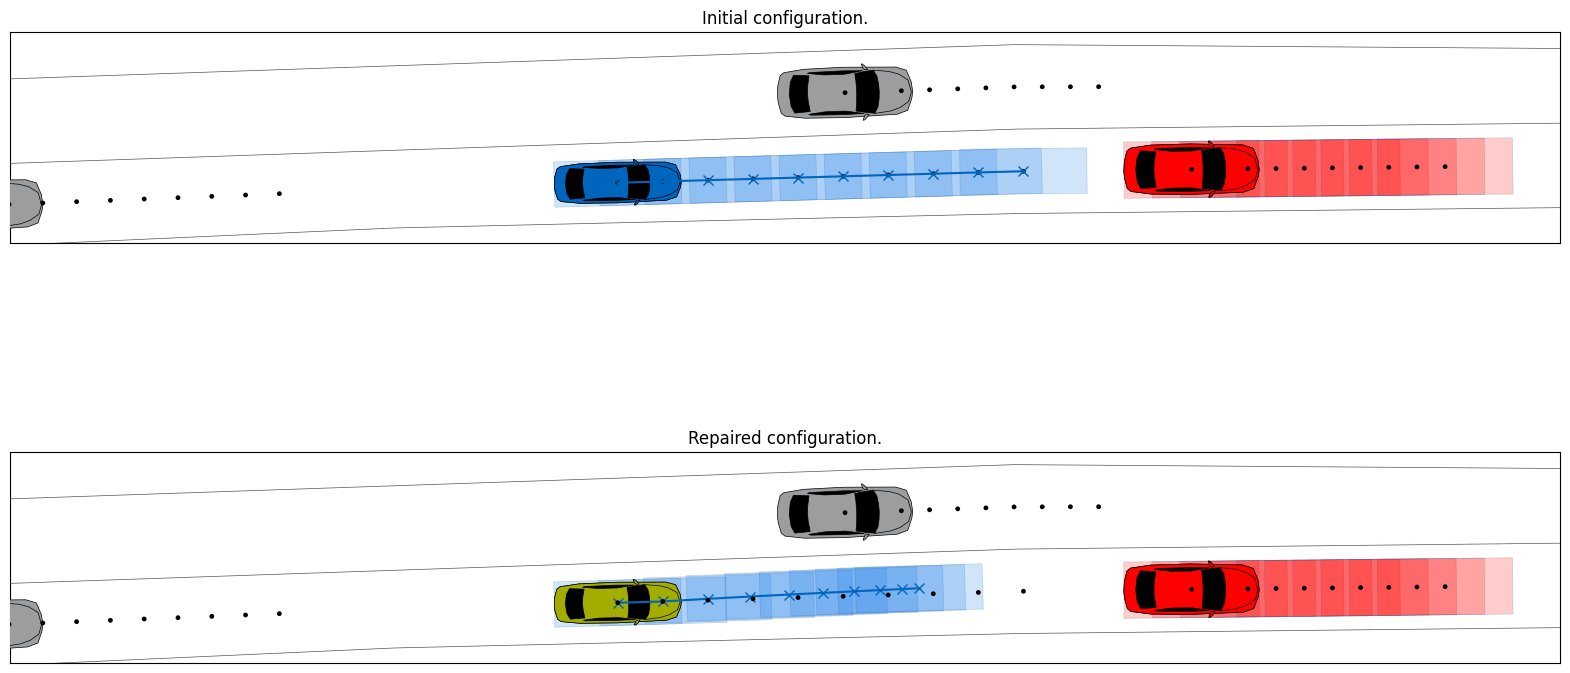

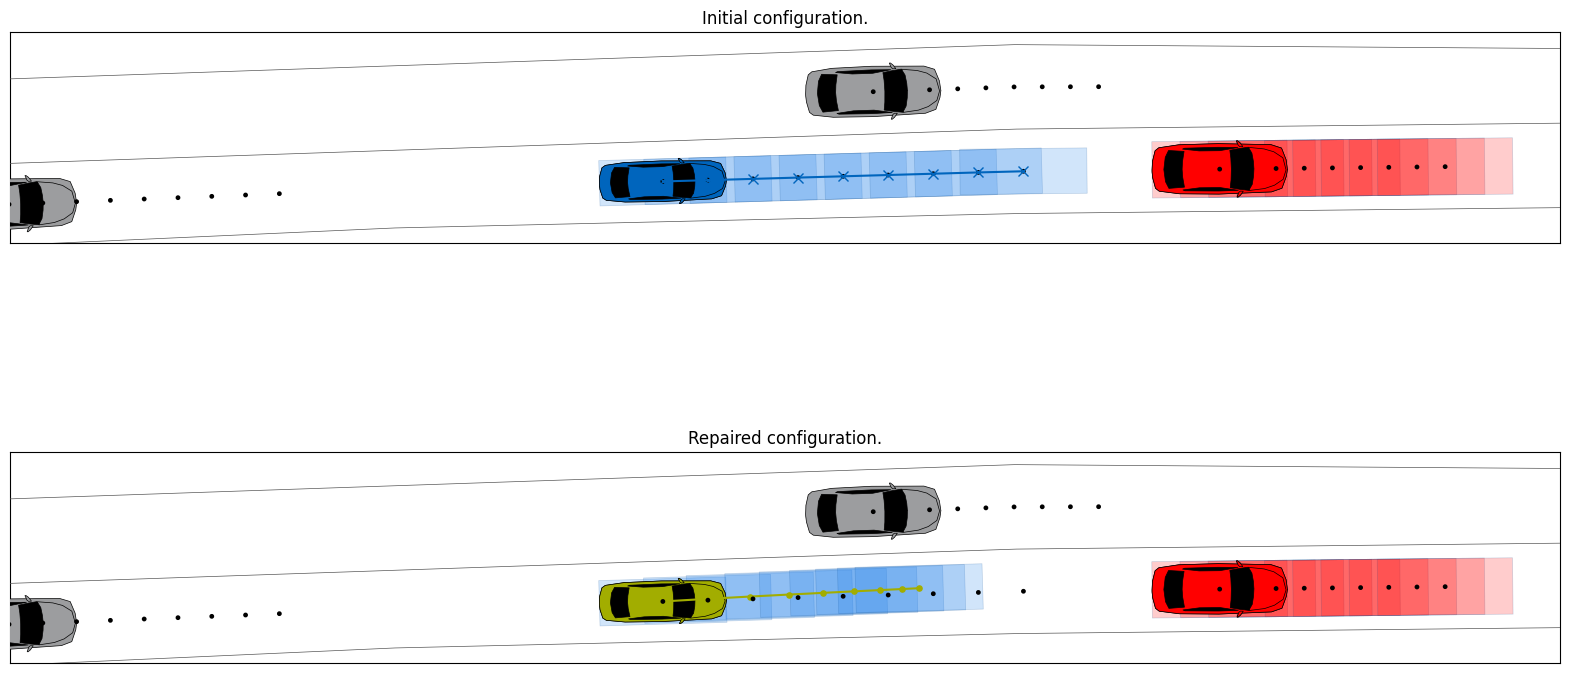

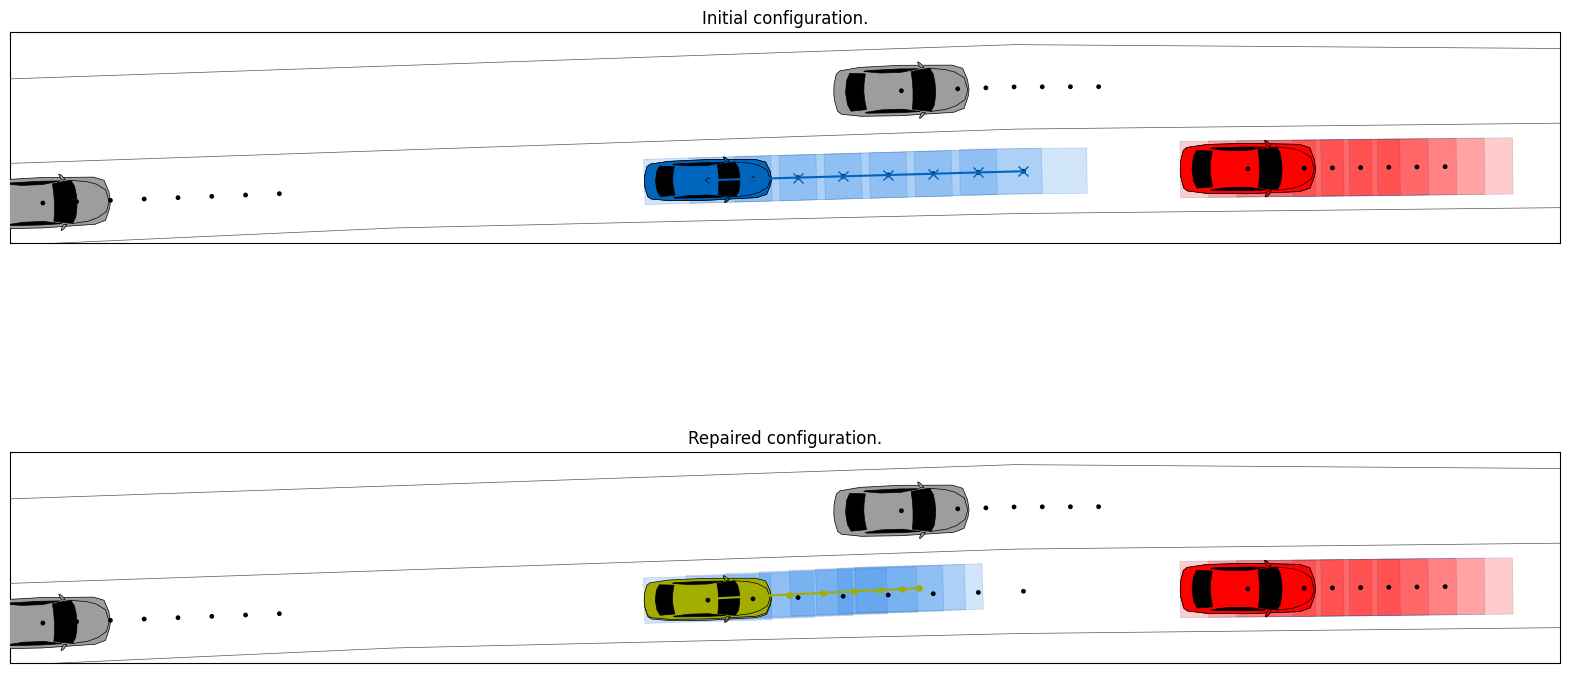

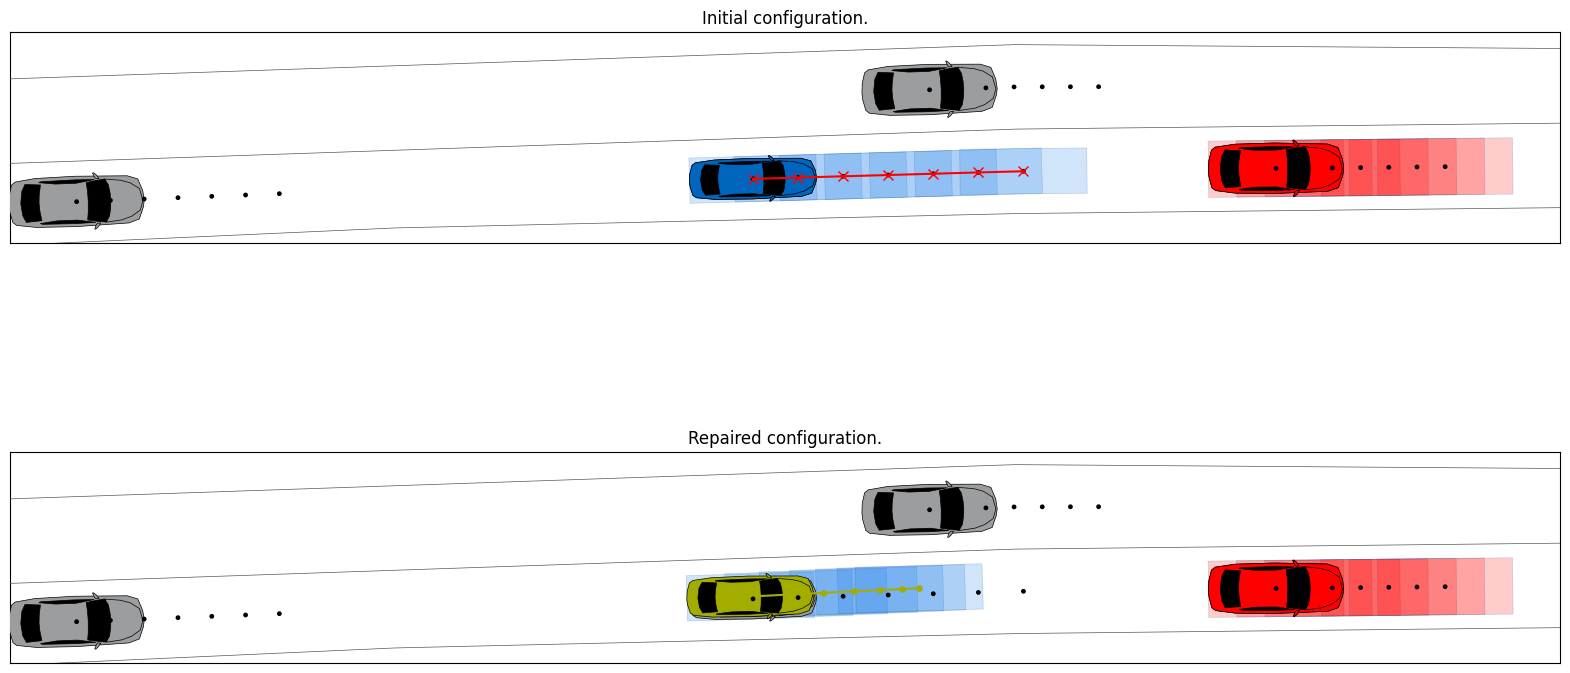

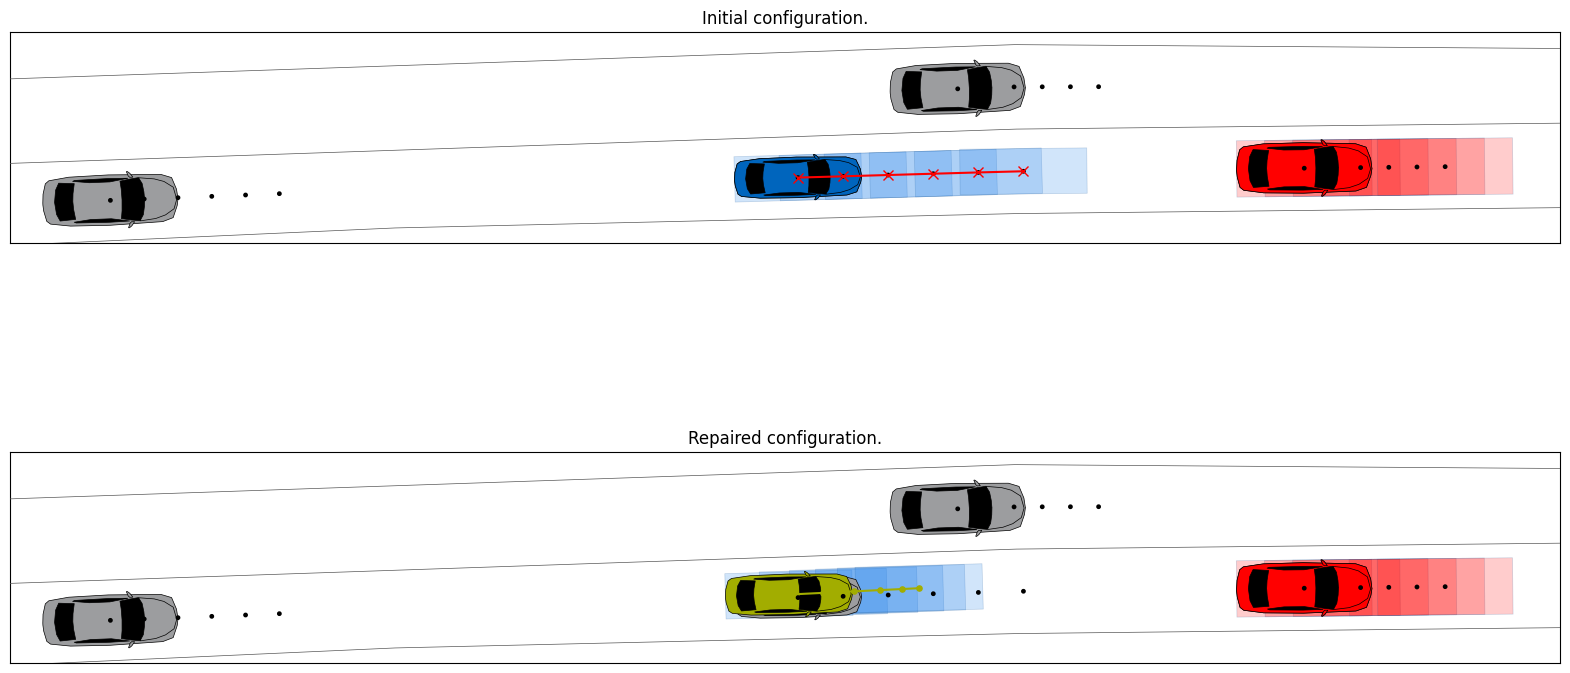

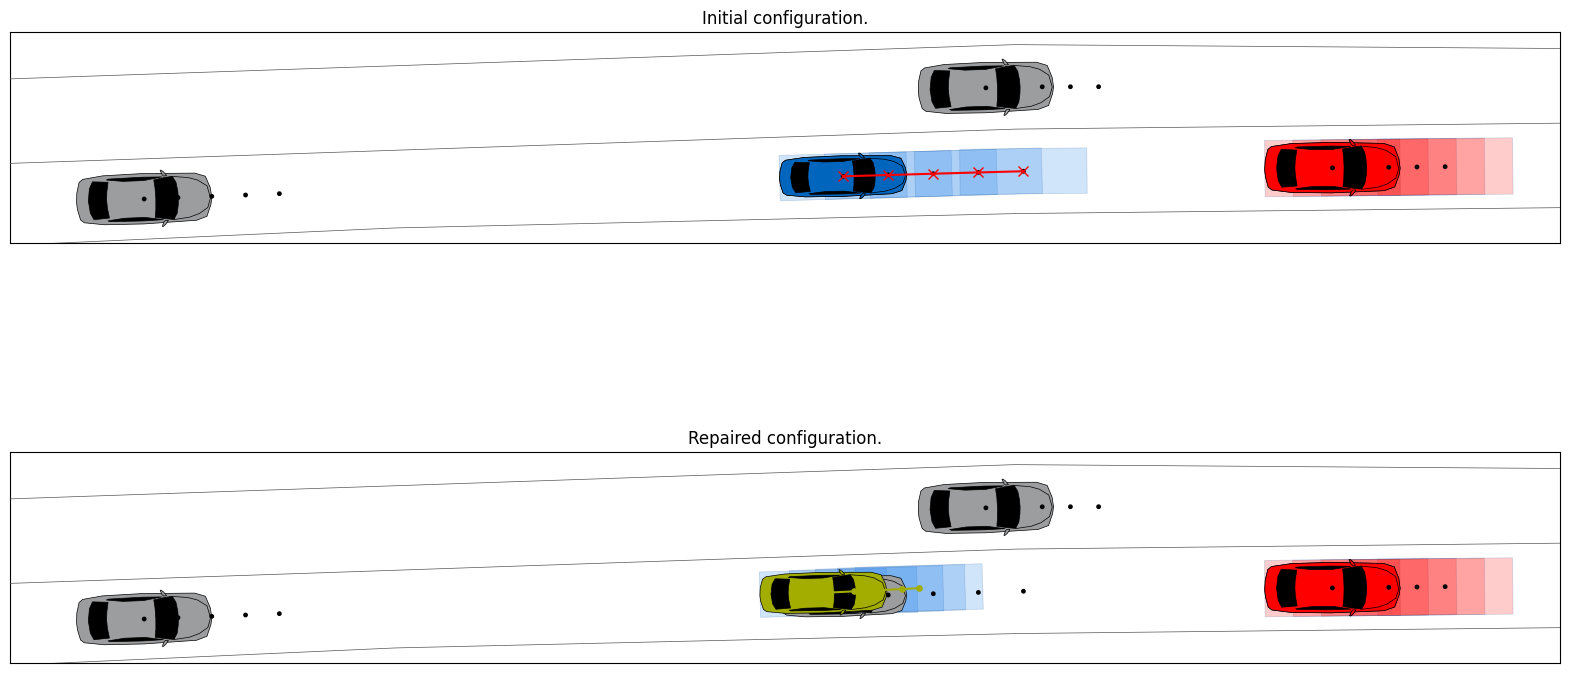

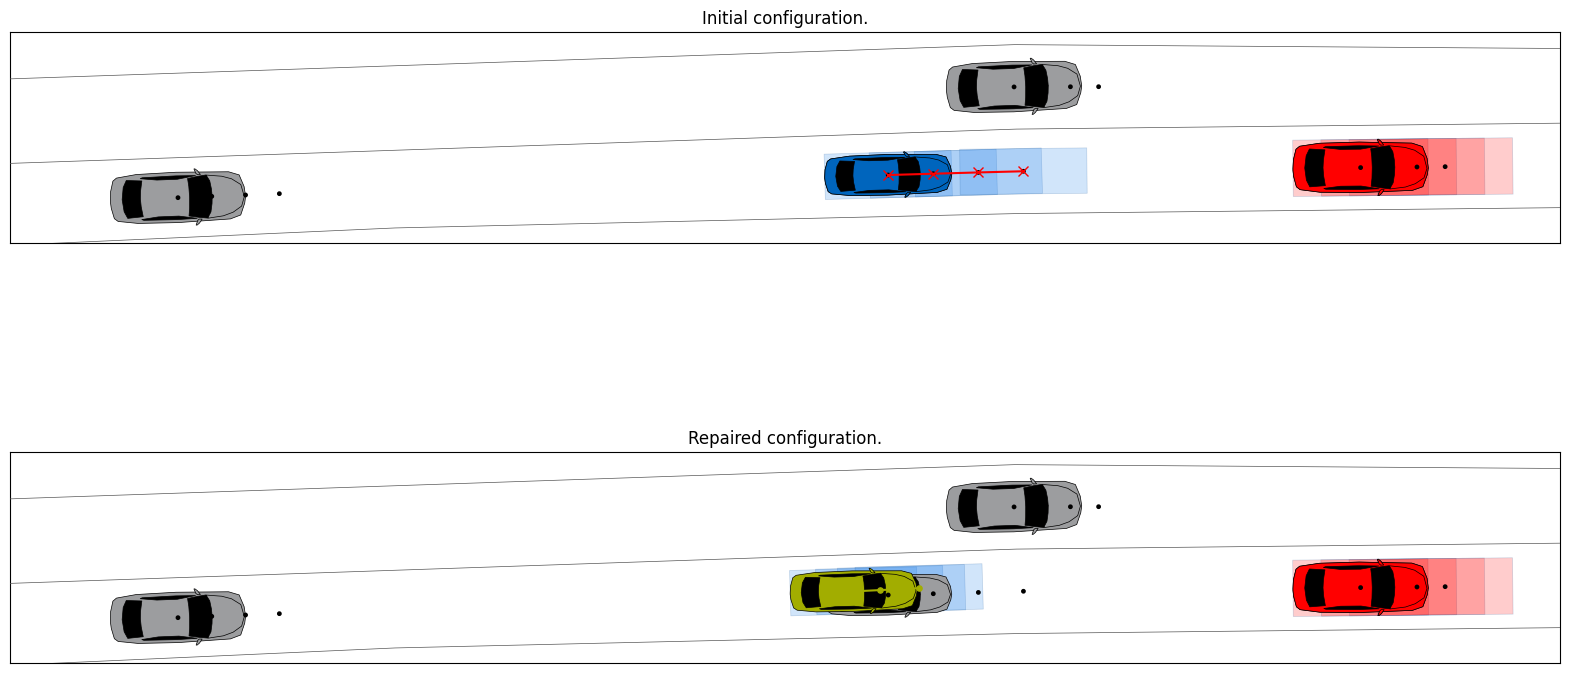

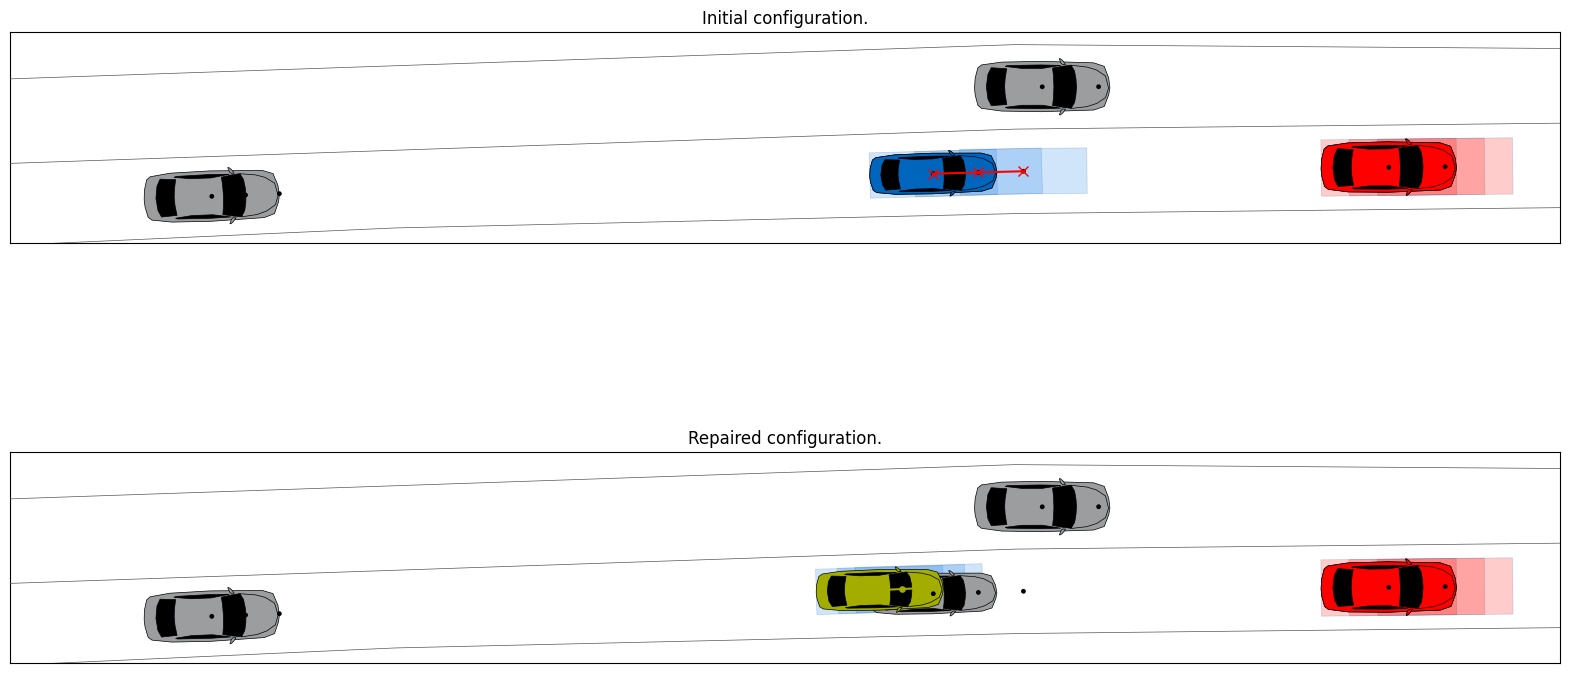

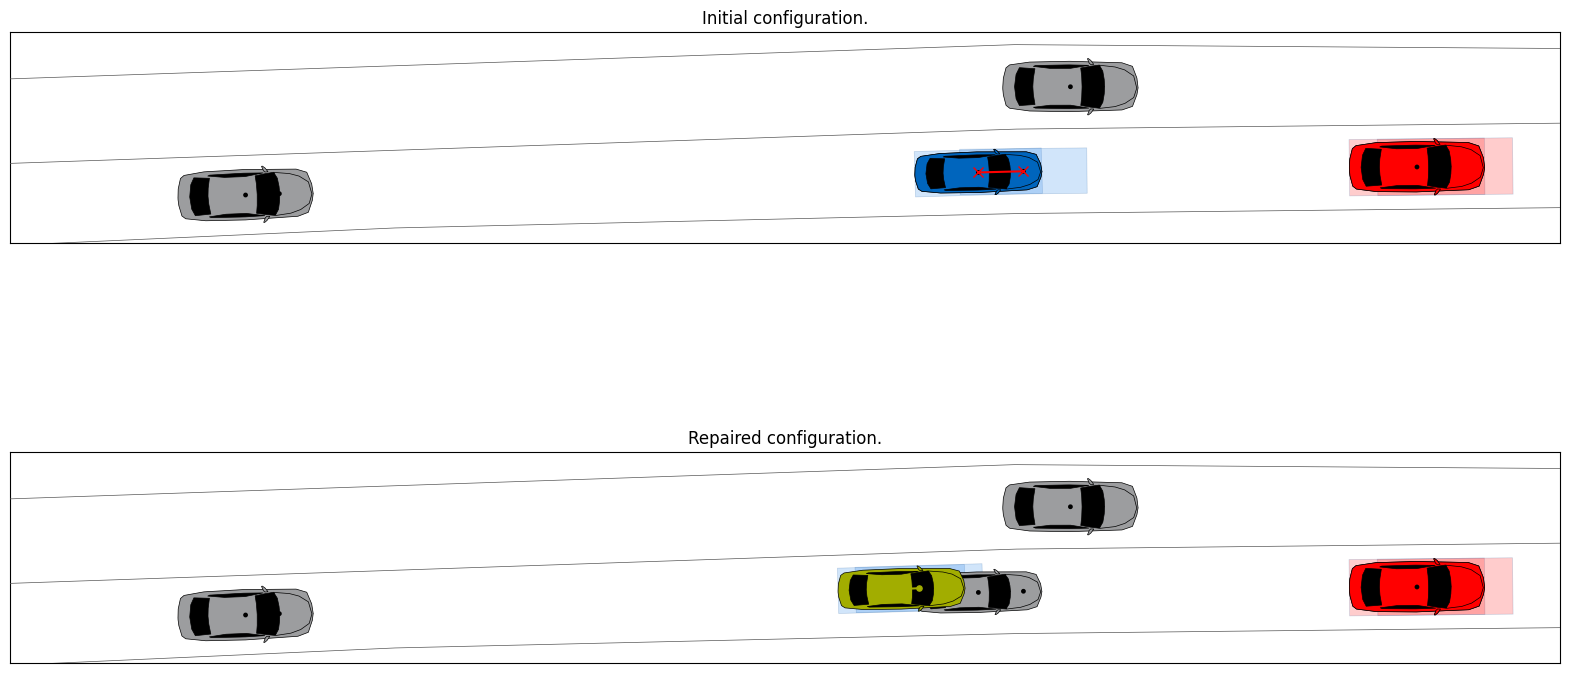

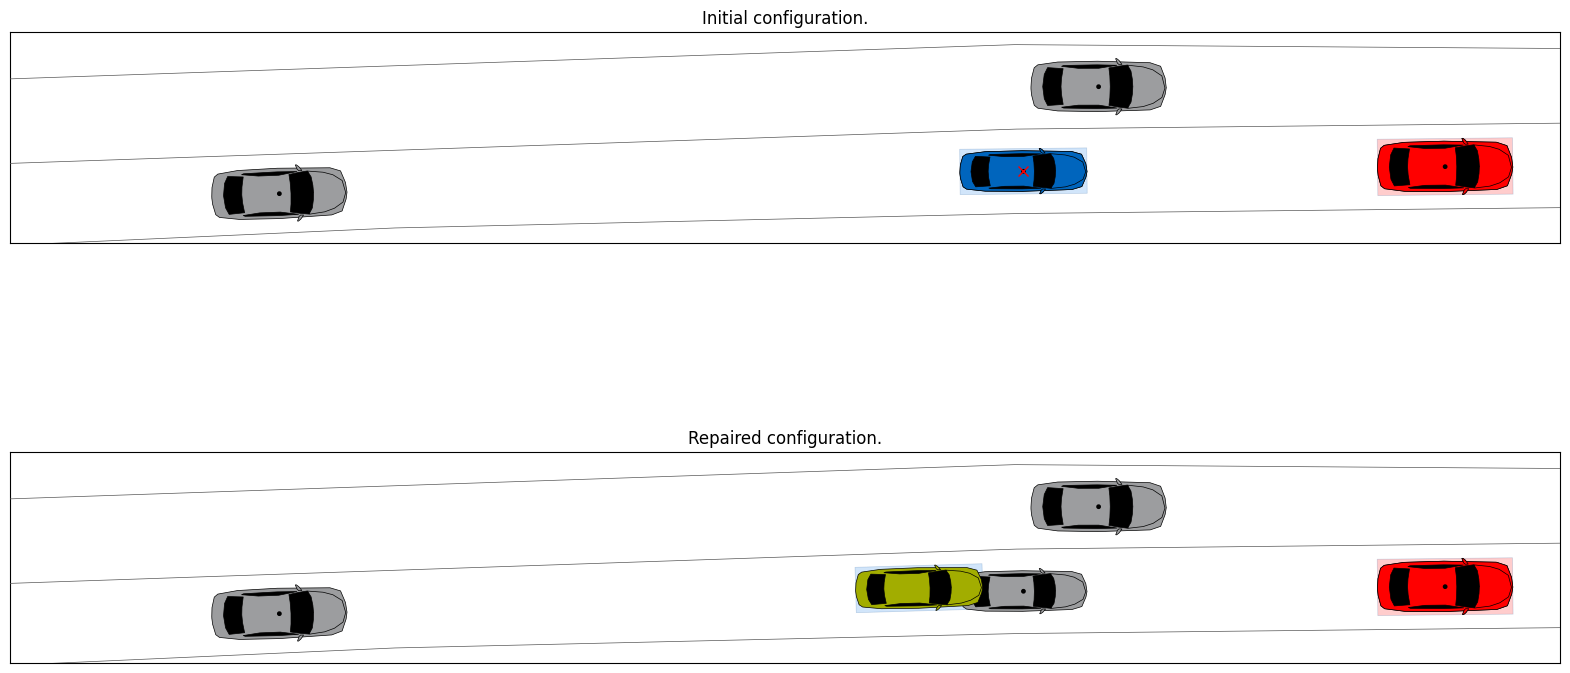

In [28]:
plot_limits = [-5, 50, -4.5, 3]

# from crrepairer.repairer.visualization import visualize_repairing_result
from crrepairer.utils.visualization import visualize_scenario

for time_step in range(ego_initial.prediction.final_time_step + 1):
    # visualize_repairing_result(scenario,
    visualize_scenario(scenario,
                               ego_initial,
                               ego_vehicle,
                               time_step,
                               tc=repairer.tc,
                               tv=repairer.tv,
                               plot_limits=plot_limits,
                               target_veh=scenario.obstacle_by_id(rule_monitor.other_id))
                            #    world_state=rule_monitor.world_state)
